In [64]:
#%%
# -*- coding: utf-8 -*-
"""
Created on Thu Jul 15 15:34:27 2021

@author: hasan
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
#%%
df = pd.read_csv('/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/labels_updated.csv')

/tmp/ipykernel_33289/1801701522.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_age = df.groupby(['gender']).mean()
/tmp/ipykernel_33289/1801701522.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  std_age = df.groupby(['gender']).std()


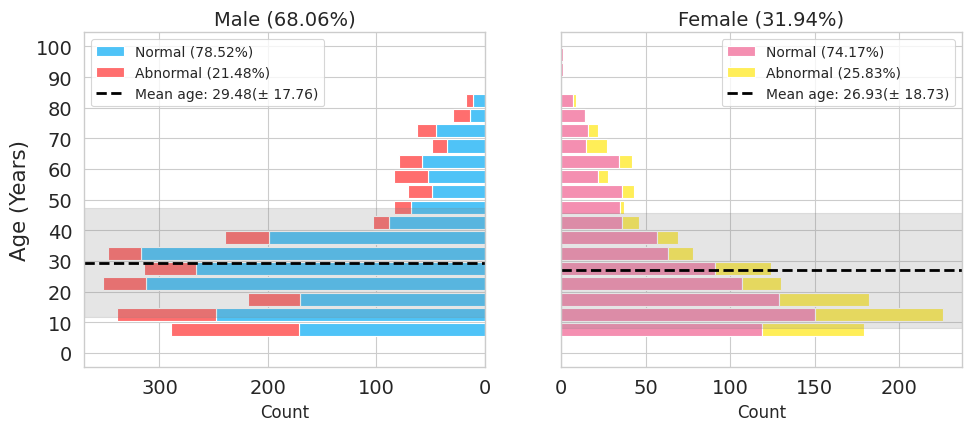

In [69]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

male_norm = df.query('gender=="male" and label=="normal"')
male_abnm = df.query('gender=="male" and label=="abnormal"')
female_norm = df.query('gender=="female" and label=="normal"')
female_abnm = df.query('gender=="female" and label=="abnormal"')
n_bins = 21
d_labels = ['Normal', 'Abnormal']

'''-------------------Calculate Stats-------------------'''
mean_age = df.groupby(['gender']).mean()
std_age = df.groupby(['gender']).std()

mean_age_male = mean_age.loc['male']['age']
std_age_male = std_age.loc['male']['age']
n_male = len(male_norm) + len(male_abnm)
p_male_norm = (len(male_norm)/n_male)*100
p_male_abnm = 100 - p_male_norm

mean_age_female = mean_age.loc['female']['age']
std_age_female = std_age.loc['female']['age']
n_female = len(female_norm) + len(female_abnm)
p_female_norm = (len(female_norm)/n_female)*100
p_female_abnm = 100 - p_female_norm

p_male = (n_male/(n_male + n_female))*100
p_female = 100 - p_male
#%%
# Adjusting color palette
normal_color_male     = '#4FC3F7'   # Sky Blue
abnormal_color_male   = '#FF6E6E'   # Coral Red
normal_color_female   = '#F48FB1'   # Rose Pink
abnormal_color_female = '#FFEE58'   # Lemon Yellow
mean_line_color = 'black'  # Black dashed line for the average

# Define the bin edges
bin_edges = np.linspace(0, 100, n_bins)

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

# Set y-ticks for both diagrams
y_ticks = np.arange(0, 101, 10)

# Male Population Histogram
ax1.hist(
    [male_norm.age, male_abnm.age],
    bins=bin_edges,
    rwidth=0.85,
    orientation='horizontal',
    stacked=True,
    color=[normal_color_male, abnormal_color_male],
    label=['Normal', 'Abnormal']
)
ax1.invert_xaxis()
ax1.set_title(f'Male ({p_male:.2f}%)', fontsize=14)
ax1.set_xlabel('Count', fontsize=12)
ax1.set_ylabel('Age (Years)')
# Set the ticks and locations for ax1
# ax1.set(yticks=y, yticklabels=[])
# for ycoord, ylbl in zip(y, ylbls):
#     ax1.annotate(ylbl, (0.51, ycoord), xycoords=('figure fraction', 'data'),
#                      ha='center', va='center')

# Add mean line and standard deviation shading
ax1.axhline(mean_age_male, color=mean_line_color, linestyle='--', linewidth=2)
ax1.add_patch(Rectangle(
    (0, mean_age_male - std_age_male), ax1.get_xlim()[0], 2 * std_age_male,
    color='gray', alpha=0.2
))
ax1.legend(
    [f'Normal ({p_male_norm:.2f}%)',
     f'Abnormal ({p_male_abnm:.2f}%)',
     f'Mean age: {mean_age_male:.2f}(\u00B1 {std_age_male:.2f})'],
    loc='upper left', fontsize=10
)

# Female Population Histogram
ax2.hist(
    [female_norm.age, female_abnm.age],
    bins=bin_edges,
    rwidth=0.85,
    orientation='horizontal',
    stacked=True,
    color=[normal_color_female, abnormal_color_female],
    label=['Normal', 'Abnormal']
)
ax2.set_title(f'Female ({p_female:.2f}%)', fontsize=14)
ax2.set_xlabel('Count', fontsize=12)
ax2.set_yticks(y_ticks)
ax2.set_yticklabels(y_ticks, fontsize=10)  # Add ticks for female diagram

# Add mean line and standard deviation shading
ax2.axhline(mean_age_female, color=mean_line_color, linestyle='--', linewidth=2)
ax2.add_patch(Rectangle(
    (0, mean_age_female - std_age_female), ax2.get_xlim()[1], 2 * std_age_female,
    color='gray', alpha=0.2
))
ax2.legend(
    [f'Normal ({p_female_norm:.2f}%)',
     f'Abnormal ({p_female_abnm:.2f}%)',
     f'Mean age: {mean_age_female:.2f}(\u00B1 {std_age_female:.2f})'],
    loc='upper right', fontsize=10
)

# Add a title and adjust layout
# plt.suptitle('Population Pyramid by Gender and Age Group', fontsize=16)
fig.tight_layout(pad=3.0, rect=[0.05, 0.05, 0.95, 0.95])

# Save and display the plot
plt.show()
fig.savefig('figures/gender_distribution_nmt_4k.png', format='png', dpi=300, bbox_inches='tight')

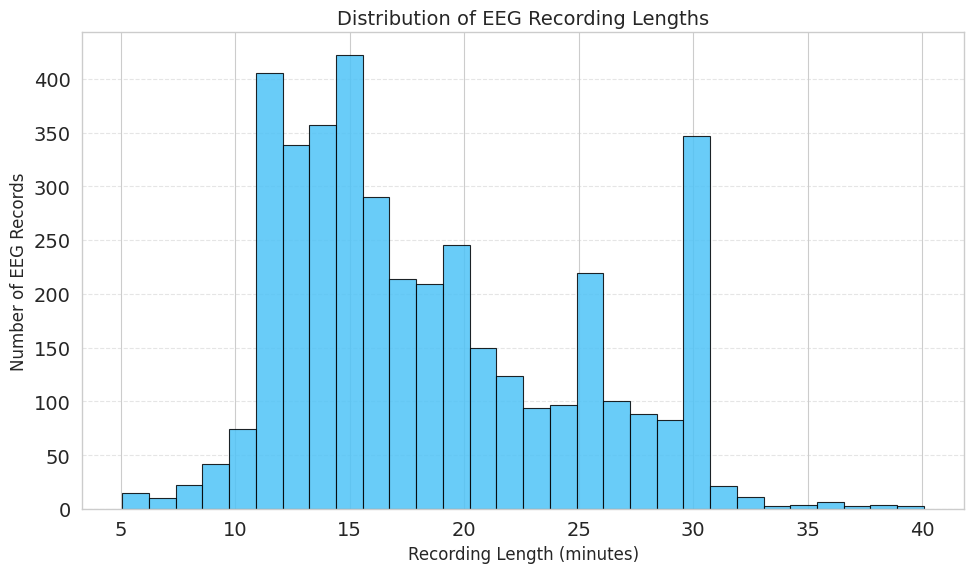

In [68]:

#%%
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data

df = pd.read_csv('/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/labels_updated.csv')
df.columns = df.columns.str.strip()

# Ensure recording length column is numeric and clean
df = df[pd.to_numeric(df["edf_length (minutes)"], errors='coerce').notna()]
df["edf_length (minutes)"] = df["edf_length (minutes)"].astype(float)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(df["edf_length (minutes)"], bins=30, color="#4FC3F7", edgecolor='black', alpha=0.85)
plt.xlabel("Recording Length (minutes)", fontsize=12)
plt.ylabel("Number of EEG Records", fontsize=12)
plt.title("Distribution of EEG Recording Lengths", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the figure
plt.savefig("figures/recording_duration_nmt_4k.png", dpi=300, bbox_inches='tight')
plt.show()



In [56]:
import mne
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
# Update this path to your actual dataset root
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")

# Dataset Structure
PARTITIONS = ["train", "eval"]
CLASSES = ["normal", "abnormal"]

# Standards
EXPECTED_SFREQ = 200
# EXPECTED_CHANNELS = {
#     'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
#     'T3', 'C3', 'Cz', 'C4', 'T4',
#     'T5', 'P3', 'Pz', 'P4', 'T6',
#     'O1', 'O2'
# }
EXPECTED_CHANNELS = {'FP1', 'FP2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'FZ', 'PZ', 'CZ'}
def check_integrity():
    print(f"Checking integrity on structured data at: {ROOT_PATH}\n")
    
    stats = {
        "total_files": 0,
        "readable": 0,
        "valid_channels": 0,
        "valid_sfreq": 0,
        "valid_duration": 0,
        "has_docx": 0,
        "has_csv": 0,
        "abnormal_count": 0  # Only abnormal files are expected to have CSVs
    }

    # Iterate through strict structure: Partition -> Class -> Modality
    files_to_check = []
    
    for part in PARTITIONS:
        for cls in CLASSES:
            # We iterate based on EDFs as the "primary" key
            edf_dir = ROOT_PATH / part / cls
            print(edf_dir)
            if not edf_dir.exists():
                continue
            
            for f in edf_dir.glob("*.edf"):
                files_to_check.append((f, part, cls))

    print(f"Found {len(files_to_check)} recordings. Validating...")

    for fpath, part, cls in tqdm(files_to_check):
        stats["total_files"] += 1
        base_name = fpath.stem
        
        # 1. Cross-Modal Checks (Path-based)
        # Define expected paths
        report_path = ROOT_PATH / part / cls / "reports" / f"{base_name}.docx"
        csv_path = ROOT_PATH / "csv_fixed_channels_fczpz_updated"/ f"{base_name}.csv"
        
        # Check DOCX (All files should have one)
        if report_path.exists():
            stats["has_docx"] += 1
            
        # Check CSV (Only Abnormal files MUST have one)
        if cls == "abnormal":
            stats["abnormal_count"] += 1
            if csv_path.exists():
                stats["has_csv"] += 1
        
        # 2. Signal Integrity Checks (Header-based)
        try:
            # Preload=False is fast (only reads header)
            raw = mne.io.read_raw_edf(fpath, preload=False, verbose=False)
            stats["readable"] += 1
            
            # Check Channels (Subset check allowing for extra channels like EKG, 
            # but ensuring 10-20 are present)
            if EXPECTED_CHANNELS.issubset(set(raw.ch_names)):
                stats["valid_channels"] += 1
                
            # Check Sampling Rate
            if raw.info['sfreq'] == EXPECTED_SFREQ:
                stats["valid_sfreq"] += 1
                
            # Check Duration Consistency (Header vs File Size logic in MNE)
            # If MNE loads it without error and n_times > 0, it's generally valid
            if raw.n_times > 0:
                stats["valid_duration"] += 1
            else:
                print(fpath)
                
        except Exception:
            pass

    # ==========================================
    # PRINT LATEX TABLE
    # ==========================================
    n = stats["total_files"]
    n_ab = stats["abnormal_count"]
    
    print(f"EDF File Readability & {stats['readable']:,} / {n:,} & {stats['readable']/n*100:.1f}\\% \\\\")
    print(f"Standard 10--20 Channel Set & {stats['valid_channels']:,} / {n:,} & {stats['valid_channels']/n*100:.1f}\\% \\\\")
    print(f"Sampling Rate (200\\,Hz) & {stats['valid_sfreq']:,} / {n:,} & {stats['valid_sfreq']/n*100:.1f}\\% \\\\")
    print(f"Header/Signal Duration Match & {stats['valid_duration']:,} / {n:,} & {stats['valid_duration']/n*100:.1f}\\% \\\\")
    print(f"Linked DOCX Reports & {stats['has_docx']:,} / {n:,} & {stats['has_docx']/n*100:.1f}\\% \\\\")
    print(f"Linked CSV Annotations (Abnormal) & {stats['has_csv']:,} / {n_ab:,} & {stats['has_csv']/n_ab*100:.1f}\\% \\\\")
   
if __name__ == "__main__":
    check_integrity()

Checking integrity on structured data at: /media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split

/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/train/normal
/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/train/abnormal
/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/eval/normal
/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/eval/abnormal
Found 4000 recordings. Validating...


100%|██████████| 4000/4000 [00:04<00:00, 892.43it/s]

EDF File Readability & 4,000 / 4,000 & 100.0\% \\
Standard 10--20 Channel Set & 4,000 / 4,000 & 100.0\% \\
Sampling Rate (200\,Hz) & 4,000 / 4,000 & 100.0\% \\
Header/Signal Duration Match & 4,000 / 4,000 & 100.0\% \\
Linked DOCX Reports & 0 / 4,000 & 0.0\% \\
Linked CSV Annotations (Abnormal) & 960 / 960 & 100.0\% \\


In [57]:
import pandas as pd
import re
from pathlib import Path
from tqdm import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
# Exact Root from your code
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")
CSV_FOLDER = ROOT_PATH / "csv_fixed_channels_fczpz_updated"

# Structure
PARTITIONS = ["train", "eval"]
TARGET_CLASS = "abnormal" 

# Standard 10-20 Channels (Case-insensitive check is best)
VALID_CHANNELS = {
    'FP1', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8',
    'T3', 'C3', 'CZ', 'C4', 'T4',
    'T5', 'P3', 'PZ', 'P4', 'T6',
    'O1', 'O2'
}

# ==========================================
# LABEL DICTIONARY & HELPERS
# ==========================================
# (Using the dictionary you provided earlier)
ab_label_dict_detail = [    
    ['Burst Suppression'],
    ['Low Voltage'],
    ['Spike and Wave'],
    ['Polyspike'],
    ['Sharp Wave'],
    ['Spike and Delta'],
    ['Triphasic Wave'],
    ['Delta Slow Wave'],
    ['Theta Wave'],
    ['Delta and Theta Wave'],
    ['Artifacts'],
    ['Normal']
]

def normalize_label(s: str) -> str:
    if pd.isna(s): return ""
    s = str(s).strip().lower()
    s = s.replace("\\", " ").replace("'", " ").replace('"', " ")
    s = re.sub(r"[_/]+", " ", s)
    s = re.sub(r"[^a-z0-9&. ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

variant2canon = {}
for g in ab_label_dict_detail:
    canonical = g[0].strip()
    for v in g:
        k = normalize_label(v)
        if k: variant2canon[k] = canonical

def parse_time_string(t_str):
    """
    Parses 'HH:MM:SS:mmm' (e.g. '00:59:47:000') into total seconds (float).
    Returns -1 if parsing fails.
    """
    try:
        if pd.isna(t_str): return -1
        t_str = str(t_str).strip()
        parts = t_str.split(':')
        if len(parts) == 4:
            # HH:MM:SS:mmm
            h, m, s, ms = map(int, parts)
            return h * 3600 + m * 60 + s + ms / 1000.0
        elif len(parts) == 3:
            # HH:MM:SS (fallback)
            h, m, s = map(float, parts)
            return h * 3600 + m * 60 + s
        else:
            return float(t_str) # Attempt direct float conversion
    except:
        return -1

# ==========================================
# MAIN CHECK LOGIC
# ==========================================
def validate_events():
    print(f"Scanning for events linked to 'abnormal' files in: {ROOT_PATH}")
    
    # 1. Identify Target CSV Files
    target_csv_paths = []
    
    for part in PARTITIONS:
        edf_dir = ROOT_PATH / part / TARGET_CLASS
        if not edf_dir.exists():
            continue
            
        for f in edf_dir.glob("*.edf"):
            base_name = f.stem
            csv_path = CSV_FOLDER / f"{base_name}.csv"
            if csv_path.exists():
                target_csv_paths.append(csv_path)

    print(f"Found {len(target_csv_paths)} matching annotation CSV files. Validating content...")
    
    # 2. Validate Content
    total_events = 0
    valid_time_count = 0
    valid_channel_count = 0
    valid_vocab_count = 0
    
    for f in tqdm(target_csv_paths):
        try:
            df = pd.read_csv(f)
            
            # --- 1. Identify Columns (Based on your CSV file structure) ---
            # Your CSV headers: 'Start time', 'End time', 'Channel names', 'Comment'
            # We map them flexibly just in case
            col_map = {c.strip().lower(): c for c in df.columns}
            
            col_start = col_map.get('start time')
            col_end = col_map.get('end time')
            col_chan = col_map.get('channel names')
            col_label = col_map.get('comment')
            
            if not (col_start and col_end):
                # Try finding them loosely if exact match fails
                col_start = next((c for c in df.columns if 'start' in c.lower()), None)
                col_end = next((c for c in df.columns if 'end' in c.lower() or 'stop' in c.lower()), None)
            
            if not (col_start and col_end):
                continue # Skip file if times missing
                
            n_rows = len(df)
            total_events += n_rows
            
            # --- Check 1: Time Ordering (End > Start) ---
            # Parse custom time format HH:MM:SS:mmm
            start_secs = df[col_start].apply(parse_time_string)
            end_secs = df[col_end].apply(parse_time_string)
            
            # Valid if numeric parse succeeded (> -0.5) AND End > Start
            valid_times = ((start_secs >= 0) & (end_secs >= 0) & (end_secs > start_secs)).sum()
            valid_time_count += valid_times
            
            # --- Check 2: Channel Validity ---
            if col_chan:
                current_valid_chans = 0
                for val in df[col_chan].fillna("").astype(str):
                    # Your CSV uses space separator: "FP1 FP2 F3..."
                    # Clean brackets/quotes just in case
                    clean_val = val.replace("'", "").replace("[", "").replace("]", "").replace('"', "").upper()
                    # Split by comma or space
                    chans_in_row = re.split(r'[,\s]+', clean_val)
                    chans_in_row = [c for c in chans_in_row if c] # remove empty
                    
                    if not chans_in_row:
                        pass
                    elif all(c in VALID_CHANNELS for c in chans_in_row):
                        current_valid_chans += 1
                valid_channel_count += current_valid_chans
            
            # --- Check 3: Vocabulary Validity ---
            if col_label:
                current_valid_vocab = 0
                for val in df[col_label]:
                    norm = normalize_label(val)
                    canon = variant2canon.get(norm, "Unknown")
                    if canon != "Unknown":
                        current_valid_vocab += 1
                valid_vocab_count += current_valid_vocab
                        
        except Exception as e:
            # print(f"Skipping {f.name}: {e}")
            pass

    # ==========================================
    # OUTPUT FOR LATEX
    # ==========================================
    print("\n" + "="*50)
    print("FINAL ROW STATISTICS (Copy these numbers)")
    print("="*50)
    print(f"Total Events (N_EVENTS): {total_events}")
    print("-" * 30)
    print(f"Time Ordering Check:  {valid_time_count}/{total_events}")
    print(f"Channel Name Check:   {valid_channel_count}/{total_events}")
    print(f"Label Vocab Check:    {valid_vocab_count}/{total_events}")
    print("="*50)

if __name__ == "__main__":
    validate_events()

Scanning for events linked to 'abnormal' files in: /media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split
Found 960 matching annotation CSV files. Validating content...


  0%|          | 0/960 [00:00<?, ?it/s]

100%|██████████| 960/960 [00:01<00:00, 561.62it/s]


FINAL ROW STATISTICS (Copy these numbers)
Total Events (N_EVENTS): 72754
------------------------------
Time Ordering Check:  72752/72754
Channel Name Check:   72754/72754
Label Vocab Check:    72754/72754


In [58]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# ==========================================
# CONFIGURATION
# ==========================================
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")
CSV_FOLDER = ROOT_PATH / "csv_fixed_channels_fczpz_updated"

# ==========================================
# ALLOWED GROUPS (The Clinical 12)
# ==========================================
ALLOWED_LABELS = {
    'Burst Suppression',
    'Low Voltage',
    'Spike and Wave',
    'Polyspike',
    'Sharp Wave',
    'Spike and Delta',
    'Triphasic Wave',
    'Delta Slow Wave',
    'Theta Wave',
    'Delta and Theta Wave',
    'Artifacts',
    'Normal'
}

def check_final_groups():
    print(f"Checking for the final 12 Clinical Groups in: {CSV_FOLDER}")
    
    csv_files = list(CSV_FOLDER.glob("*.csv"))
    total_rows = 0
    valid_count = 0
    invalid_count = 0
    invalid_labels = Counter()
    
    for f in tqdm(csv_files):
        try:
            df = pd.read_csv(f)
            # Smart column finder
            col_map = {c.strip().lower(): c for c in df.columns}
            col_label = col_map.get('comment') or next((c for c in df.columns if 'label' in c.lower()), None)
            
            if not col_label: continue
            
            for label in df[col_label]:
                total_rows += 1
                label_str = str(label).strip()
                
                if label_str in ALLOWED_LABELS:
                    valid_count += 1
                else:
                    invalid_count += 1
                    invalid_labels[label_str] += 1
                    
        except Exception as e:
            print(f"Error reading {f.name}: {e}")

    print("\n" + "="*60)
    print("FINAL VALIDATION REPORT")
    print("="*60)
    print(f"Total Rows:      {total_rows}")
    print(f"Valid Rows:      {valid_count}")
    print(f"Invalid Rows:    {invalid_count}")
    
    if invalid_count == 0:
        print("\n✅ SUCCESS: Dataset is strictly mapped to the 12 Clinical Groups.")
    else:
        print("\n❌ WARNING: Found invalid labels:")
        for k, v in invalid_labels.most_common():
            print(f"{v} | {k}")

if __name__ == "__main__":
    check_final_groups()

Checking for the final 12 Clinical Groups in: /media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated


100%|██████████| 960/960 [00:00<00:00, 1340.98it/s]


FINAL VALIDATION REPORT
Total Rows:      72754
Valid Rows:      72754
Invalid Rows:    0

✅ SUCCESS: Dataset is strictly mapped to the 12 Clinical Groups.


Success! Plot saved to: figures/fig_signal_qc_grid.png


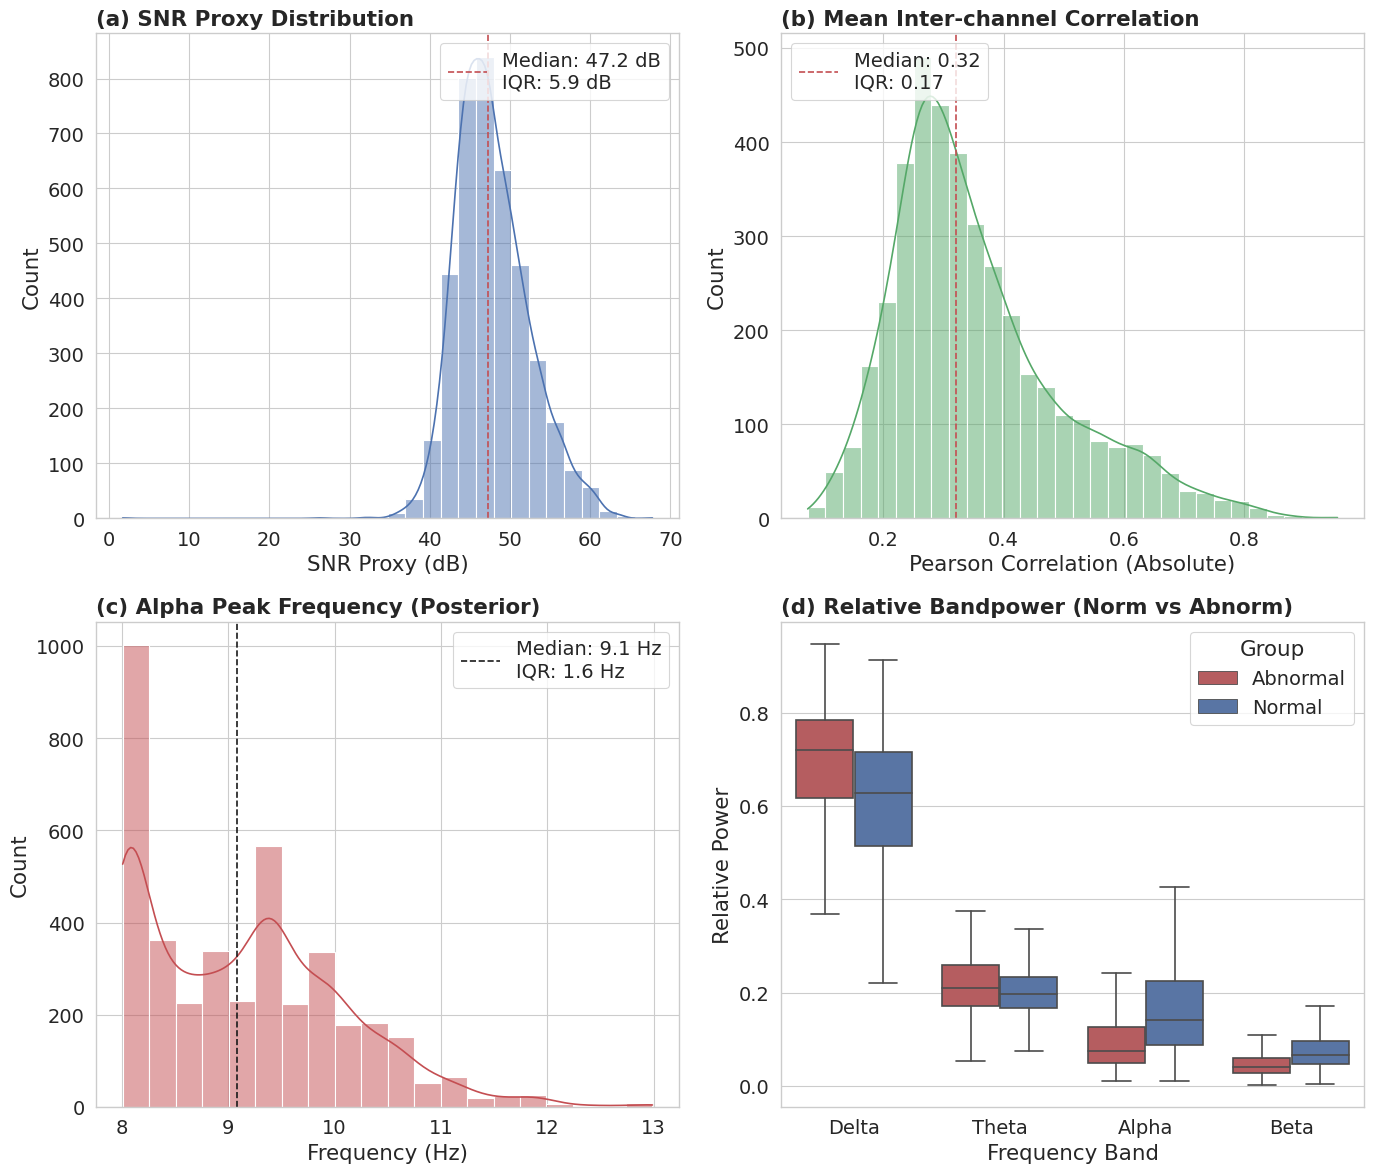

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# CONFIGURATION
# ==========================================
CSV_FILE = "nmt4k_stats_output.csv"
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_FILENAME = OUTPUT_DIR / "fig_signal_qc_grid.png"

# Set style for publication quality with BIGGER FONTS
# Increased font_scale from 1.2 to 1.6
sns.set_theme(style="whitegrid", context="paper", font_scale=1.6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (14, 12)  # Slightly larger figure size

def plot_signal_qc(csv_path):
    # 1. Load Data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: Could not find {csv_path}. Run the calculation script first.")
        return

    # Filter out potential NaNs for specific plots
    df_snr = df['snr'].dropna()
    df_corr = df['correlation'].dropna()
    df_alpha = df['alpha_peak'].dropna()
    
    # Prepare Data for Bandpower Plot (Melt for Seaborn)
    bp_cols = ['Delta', 'Theta', 'Alpha', 'Beta']
    df_bp = df.melt(id_vars=['group'], value_vars=bp_cols, 
                    var_name='Band', value_name='Relative Power')
    
    # Exclude 'Unknown' groups if necessary
    df_bp = df_bp[df_bp['group'].isin(['Normal', 'Abnormal'])]

    # ==========================================
    # CREATE FIGURE (2x2 GRID)
    # ==========================================
    fig, axes = plt.subplots(2, 2)
    ax = axes.flatten()

    # Helper function to compute Median & IQR and format label
    def get_stats_label(data, unit="", decimals=1):
        median = data.median()
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1
        # Format string with Median and IQR
        return f'Median: {median:.{decimals}f}{unit}\nIQR: {iqr:.{decimals}f}{unit}'

    # --- (a) SNR Proxy Distribution ---
    sns.histplot(df_snr, ax=ax[0], kde=True, color="#4C72B0", bins=30)
    ax[0].set_title("(a) SNR Proxy Distribution", fontweight='bold', loc='left')
    ax[0].set_xlabel("SNR Proxy (dB)")
    ax[0].set_ylabel("Count")
    
    # Calculate stats
    label_snr = get_stats_label(df_snr, unit=" dB", decimals=1)
    ax[0].axvline(df_snr.median(), color='r', linestyle='--', label=label_snr)
    ax[0].legend(loc='upper right', frameon=True)

    # --- (b) Inter-channel Correlation ---
    sns.histplot(df_corr, ax=ax[1], kde=True, color="#55A868", bins=30)
    ax[1].set_title("(b) Mean Inter-channel Correlation", fontweight='bold', loc='left')
    ax[1].set_xlabel("Pearson Correlation (Absolute)")
    ax[1].set_ylabel("Count")
    
    # Calculate stats
    label_corr = get_stats_label(df_corr, unit="", decimals=2)
    ax[1].axvline(df_corr.median(), color='r', linestyle='--', label=label_corr)
    ax[1].legend(loc='upper left', frameon=True)

    # --- (c) Alpha Peak Frequency ---
    valid_alpha = df_alpha[(df_alpha >= 7) & (df_alpha <= 14)]
    sns.histplot(valid_alpha, ax=ax[2], kde=True, color="#C44E52", bins=20)
    ax[2].set_title("(c) Alpha Peak Frequency (Posterior)", fontweight='bold', loc='left')
    ax[2].set_xlabel("Frequency (Hz)")
    ax[2].set_ylabel("Count")
    
    # Calculate stats
    label_alpha = get_stats_label(valid_alpha, unit=" Hz", decimals=1)
    ax[2].axvline(valid_alpha.median(), color='k', linestyle='--', label=label_alpha)
    ax[2].legend(loc='upper right', frameon=True)

    # --- (d) Bandpower Comparison (Normal vs Abnormal) ---
    sns.boxplot(data=df_bp, x='Band', y='Relative Power', hue='group', 
                ax=ax[3], palette={'Normal': '#4C72B0', 'Abnormal': '#C44E52'},
                showfliers=False)
    ax[3].set_title("(d) Relative Bandpower (Norm vs Abnorm)", fontweight='bold', loc='left')
    ax[3].set_xlabel("Frequency Band")
    ax[3].set_ylabel("Relative Power")
    ax[3].legend(title="Group", loc='upper right', frameon=True)

    # ==========================================
    # FINALIZE AND SAVE
    # ==========================================
    plt.tight_layout()
    plt.savefig(OUTPUT_FILENAME, dpi=300, bbox_inches='tight')
    print(f"Success! Plot saved to: {OUTPUT_FILENAME}")

if __name__ == "__main__":
    plot_signal_qc(CSV_FILE)

In [60]:
import pandas as pd
import re
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# ==========================================
# CONFIGURATION
# ==========================================
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")
CSV_FOLDER = ROOT_PATH / "csv_fixed_channels_fczpz_updated"

# ==========================================
# 1. COMPREHENSIVE CLINICAL DICTIONARY
# ==========================================
label_dict = [
    # -------------------------------------------------------------
    # GROUP 1: CRITICAL / SUPPRESSION (The "Flat" Family)
    # -------------------------------------------------------------
    # 1. Burst Suppression 
    # Critical pattern: Flat line interrupted by high-voltage bursts.
    ['burst suppression', 'suppression', 'burst-suppression', 'bursts and suppression', 
     'generalized burst suppression', 'Burst Suppression'],

    # 2. Low Voltage 
    # Critical pattern: Consistent low amplitude or flat line (isoelectric).
    ['low voltage', 'no waveform', 'low volatge', 'loww voltage', 'low volage',
     'no electrical activity', 'no electrical effects', 'no elecctrical activity',
     'no electrical avtivity', 'no electrtical activity',
     'no voltage', 'flat', 'isoelectric', 'attenuation', 'electrocerebral silence',
     'low volatge (no waveform)', 'background attenuation', 'suppressed background',
     'Low Voltage'],

    # -------------------------------------------------------------
    # GROUP 2: EPILEPTIFORM (The "Irritative" Family)
    # -------------------------------------------------------------
    # 3. Spike and Wave 
    # The classic seizure marker.
    ['spike and wave', 'spike', 'spikes', 'spike wave', '3hz spike and wave', 
     'generalized spike and wave', 'generalized spike and wave discharge',
     'generalized periodic epileptiform discharges', 'gped', 'gpeds', 'pleds', 
     'ped', 'peds', 'periodic discharges', 'spike/wave', 'spk', 'sw', 'gsw', 
     'spike-wave', '2 hertz slow spike and wave discharge', 'slow spike and wave',
     'rolandic spike', 'rolandic spikes', 'focal spikes', 'multifocal spikes',
     'generalized paroxysmal spike and wave discharge', 
     'generalized paroxymal spike and wave discharge',
     'spike and wave discharge', 'fragmented spike and wave discharge',
     'Spike and Wave'],

    # 4. Polyspike 
    # Multiple fast spikes.
    ['polyspike', 'polyspikes', 'polyspikes ', 'polyspike and wave', 
     'polyspikes and wave', 'polypspikes and wave', 'generalized polyspikes', 
     'generalized polyspikes discharge', 'polyspikes discharge', 
     'generalized polyspike discharge', 'spike & polyspike', 
     'spike & polyspike wave', 'spike & polyspike and wave',
     'generalized spike & polyspike pattern', 'spike and polyspike', 
     'generalized spike & polyspike wave', 'spike/polyspike',
     'Polyspike'],

    # 5. Sharp Wave 
    # Slower than a spike (70-200ms).
    ['sharp waves', 'sharp wave', 'generalized sharp waves',
     'generalized sharp waves discharge', 'sharp', 'sharp and slow',
     'sharp and slow wave', 'focal sharp waves', 'multifocal sharp waves',
     'vertex sharp waves', 'biphasic sharp waves',
     'Sharp Wave'],

    # 6. Spike and Delta (Active Epileptiform + Slowing)
    # Mixed pattern where both are prominent.
    ['spike and delta slow waves', 'spike and delta', 
     'spike and wave discharges followed by generalized slowing',
     'spike and wave discharges with generalized slowing',
     'spike and slow wave', 'spikes and slowing',
     'Spike and Delta'],

    # -------------------------------------------------------------
    # GROUP 3: ENCEPHALOPATHY (The "Slowing" Family)
    # -------------------------------------------------------------
    # 7. Triphasic Wave 
    # Metabolic pattern (liver/kidney failure).
    ['triphasic waves', 'triphasic', 'triphaic waves', 'triphasic morphology',
     'generalized triphasic waves',
     'Triphasic Wave'],

    # 8. Delta Slowing 
    # Deep slowing (<4Hz).
    ['delta slow wave', 'delta waves', 'delta', 'slowing', 
     'generalized slowing', 'generalized delta', 'focal slowing',
     'slow waves', 'intermittent rhythmic delta activity', 'firda', 'oda', 'irda',
     'generalized delta slow waves', 'paroxysmal delta slow waves',
     'generalized paroxymal delta slow waves', 'diffuse slowing', 'continuous slowing',
     'slow wave', 'slow wave activity', 'dela slow waves',
     'sharp and delta slow waves', # Usually dominated by slow component
     'Delta Slow Wave'],

    # 9. Theta Slowing
    # Moderate slowing (4-7Hz).
    ['theta waves', 'theta wave', 'theta slow waves', 'theta', 'theta slowing',
     'generalized slowing in theta range', 'focal theta',
     'Theta Wave'],

    # 10. Mixed Slowing (Delta + Theta)
    ['delta and theta waves', 'delta-theta slowing', 'delta/theta',
     'frontal dela to theta slowing', 'generalized slowing in delta to theta range',
     'generalized slowing in delta-thta range', 'mixed slowing',
     'Delta and Theta Wave'],

    # -------------------------------------------------------------
    # GROUP 4: NOISE & NORMAL
    # -------------------------------------------------------------
    # 11. Artifacts 
    # Non-brain signals.
    ['artifact', 'movement', 'muscle', 'blink', 'chewing', 'electrode', 'pop', '60hz', 'ekg',
     'Artifracts', 'articats', 'artifacds', 'artifacts', 'frontal area artifacts',
     'eye movement', 'emg', 'mains noise', 'sweat artifact',
     'Artifacts'],

    # 12. Normal / Background 
    # Healthy or Unlabeled.
    ['Normal', 'Beta Wave', 'beta waves', 'beta activity', 'beta', 'fast activity',
     'Alpha Coma', 'alpha coma', 'alpha rhythm', 'posterior dominant rhythm',
     'No Comment', 'nan', 'Unknown', 'trace', 'delete previous', 'v', 
     'end of file', 'data', 'file', 'sleep spindles', 'k-complex', 'vertex waves',
     'Normal']
]

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def normalize_label(s: str) -> str:
    if pd.isna(s): return "nan"
    s = str(s).strip().lower()
    # Remove special chars but keep spaces
    s = s.replace("\\", " ").replace("'", " ").replace('"', " ").replace(":", "")
    s = re.sub(r"[_/]+", " ", s)
    s = re.sub(r"[^a-z0-9 ]+", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

lookup_map = {}
for group in label_dict:
    target = group[-1]
    lookup_map[normalize_label(target)] = target
    for variant in group[:-1]:
        norm = normalize_label(variant)
        if norm:
            lookup_map[norm] = target

def get_clinical_label(raw_label):
    norm = normalize_label(raw_label)
    
    # 1. Exact Match (Fastest)
    if norm in lookup_map:
        return lookup_map[norm]
    
    # 2. Fuzzy Logic Hierarchy (Crucial Order!)
    # We must check "Complex" patterns first to avoid partial matching.
    
    # --- Critical Patterns ---
    if 'burst' in norm: return 'Burst Suppression'
    if 'triphasic' in norm: return 'Triphasic Wave'
    
    # --- Mixed Patterns ---
    # "Spike and Delta" must be checked before "Delta" or "Spike" alone
    if 'spike' in norm and 'delta' in norm: return 'Spike and Delta'
    if 'delta' in norm and 'theta' in norm: return 'Delta and Theta Wave'
    if 'polyspike' in norm: return 'Polyspike' # Catches mixed "spike & polyspike"
    
    # --- Pure Epileptiform ---
    if 'spike' in norm: return 'Spike and Wave'
    if 'periodic' in norm and 'discharge' in norm: return 'Spike and Wave' # PLEDs/GPEDs
    if 'sharp' in norm: return 'Sharp Wave'
    
    # --- Pure Slowing ---
    if 'theta' in norm: return 'Theta Wave'
    if 'delta' in norm: return 'Delta Slow Wave'
    if 'slow wave' in norm: return 'Delta Slow Wave'
    if 'slowing' in norm: return 'Delta Slow Wave' # Generic slowing -> Delta (safest clinical assumption for "abnormal")
    
    # --- Suppression/Artifact ---
    if 'low voltage' in norm or 'no voltage' in norm: return 'Low Voltage'
    if 'electrical activity' in norm: return 'Low Voltage'
    if 'isoelectric' in norm: return 'Low Voltage'
    if 'artifact' in norm: return 'Artifacts'
    
    # --- Normal / Fallback ---
    if 'beta' in norm: return 'Normal'
    if 'alpha' in norm: return 'Normal' # Usually normal background (except Alpha Coma, which fits here as non-epileptic)
    
    # If it's truly unrecognizable, we map to Normal (Background) rather than crashing
    return "Normal"

# ==========================================
# 3. UPDATE SCRIPT
# ==========================================
def update_csvs_to_clinical_norm():
    print("Updating CSVs to COMPREHENSIVE Doctor-Approved Clinical Norms...")
    
    csv_files = list(CSV_FOLDER.glob("*.csv"))
    
    total_labels = 0
    stats = Counter()
    
    for f in tqdm(csv_files):
        try:
            df = pd.read_csv(f)
            col_map = {c.strip().lower(): c for c in df.columns}
            col_label = col_map.get('comment') or next((c for c in df.columns if 'label' in c.lower()), None)
            
            if not col_label: continue
            
            new_labels = []
            for raw_val in df[col_label]:
                total_labels += 1
                cat = get_clinical_label(raw_val)
                new_labels.append(cat)
                stats[cat] += 1
            
            df[col_label] = new_labels
            df.to_csv(f, index=False)
            
        except Exception as e:
            print(f"Error: {e}")

    print("\n" + "="*50)
    print("CLINICAL UPDATE COMPLETE")
    print("="*50)
    print(f"Total Labels: {total_labels}")
    print("-" * 30)
    for k, v in stats.most_common():
        print(f"{v:6d} | {k}")

if __name__ == "__main__":
    update_csvs_to_clinical_norm()

Updating CSVs to COMPREHENSIVE Doctor-Approved Clinical Norms...


100%|██████████| 960/960 [00:01<00:00, 687.84it/s]


CLINICAL UPDATE COMPLETE
Total Labels: 72754
------------------------------
 23367 | Delta Slow Wave
 17641 | Spike and Wave
 13546 | Sharp Wave
  9351 | Low Voltage
  6339 | Theta Wave
  1225 | Normal
   557 | Triphasic Wave
   235 | Artifacts
   162 | Delta and Theta Wave
   150 | Polyspike
    91 | Spike and Delta
    90 | Burst Suppression


In [61]:
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")
CSV_FOLDER = ROOT_PATH / "csv_fixed_channels_fczpz_updated"

def generate_latex_rows():
    print(f"Scanning {CSV_FOLDER}...")
    
    stats = Counter()
    total_events = 0
    
    # 1. TALLY ALL EVENTS
    csv_files = list(CSV_FOLDER.glob("*.csv"))
    for f in tqdm(csv_files):
        try:
            df = pd.read_csv(f)
            # Smart column finder
            col_map = {c.strip().lower(): c for c in df.columns}
            col_label = col_map.get('comment') or next((c for c in df.columns if 'label' in c.lower()), None)
            
            if col_label:
                labels = df[col_label].astype(str).tolist()
                stats.update(labels)
                total_events += len(labels)
        except:
            pass

    # 2. DEFINE TABLE ORDER
    # (Category Name, Label in CSV)
    table_rows = [
        # Critical
        ("Burst Suppression", "Burst Suppression"),
        ("Low Voltage",       "Low Voltage"),
        # Epileptiform
        ("Spike and Wave",    "Spike and Wave"),
        ("Polyspike",         "Polyspike"),
        ("Sharp Wave",        "Sharp Wave"),
        ("Spike and Delta",   "Spike and Delta"),
        # Slowing
        ("Triphasic Wave",    "Triphasic Wave"),
        ("Delta Slow Wave",   "Delta Slow Wave"),
        ("Theta Wave",        "Theta Wave"),
        ("Delta and Theta",   "Delta and Theta Wave"), # Maps 'Wave' in CSV to 'Delta and Theta' in Table
        # Other
        ("Artifacts",         "Artifacts"),
        ("Normal",            "Normal")
    ]

    # 3. PRINT LATEX ROWS
    print("\n" + "="*50)
    print("COPY THESE ROWS INTO YOUR LATEX TABLE")
    print("="*50)
    
    for table_name, csv_label in table_rows:
        count = stats[csv_label]
        if total_events > 0:
            pct = (count / total_events) * 100
        else:
            pct = 0.0
            
        # Matches LaTeX format: & Label & Count & \% \\
        print(f" & {table_name:<20} & \\textbf{{{count:,}}} & {pct:.1f} \\\\")
        
    print("="*50)
    print(f"Total Events: {total_events}")

if __name__ == "__main__":
    generate_latex_rows()

Scanning /media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv_fixed_channels_fczpz_updated...


100%|██████████| 960/960 [00:00<00:00, 1289.15it/s]


COPY THESE ROWS INTO YOUR LATEX TABLE
 & Burst Suppression    & \textbf{90} & 0.1 \\
 & Low Voltage          & \textbf{9,351} & 12.9 \\
 & Spike and Wave       & \textbf{17,641} & 24.2 \\
 & Polyspike            & \textbf{150} & 0.2 \\
 & Sharp Wave           & \textbf{13,546} & 18.6 \\
 & Spike and Delta      & \textbf{91} & 0.1 \\
 & Triphasic Wave       & \textbf{557} & 0.8 \\
 & Delta Slow Wave      & \textbf{23,367} & 32.1 \\
 & Theta Wave           & \textbf{6,339} & 8.7 \\
 & Delta and Theta      & \textbf{162} & 0.2 \\
 & Artifacts            & \textbf{235} & 0.3 \\
 & Normal               & \textbf{1,225} & 1.7 \\
Total Events: 72754


In [62]:
import pandas as pd
from pathlib import Path
import numpy as np

# CONFIG
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")
CSV_FOLDER = ROOT_PATH / "csv_fixed_channels_fczpz_updated"

# TAXONOMY MAPPING
FAMILY_MAP = {
    'Burst Suppression': 'Critical', 'Low Voltage': 'Critical',
    'Spike and Wave': 'Epileptiform', 'Polyspike': 'Epileptiform',
    'Sharp Wave': 'Epileptiform', 'Spike and Delta': 'Epileptiform',
    'Triphasic Wave': 'Slowing', 'Delta Slow Wave': 'Slowing',
    'Theta Wave': 'Slowing', 'Delta and Theta Wave': 'Slowing',
    'Artifacts': 'Other', 'Normal': 'Other'
}

def get_seconds(time_str):
    # Convert HH:MM:SS:mmm to seconds
    # Replace last colon with dot for millisecond parsing
    try:
        parts = time_str.rsplit(':', 1)
        clean_time = f"{parts[0]}.{parts[1]}"
        t = pd.to_datetime(clean_time, format="%H:%M:%S.%f")
        return t.hour * 3600 + t.minute * 60 + t.second + t.microsecond / 1e6
    except:
        return np.nan

def calculate_paper_stats():
    print("Calculating Event Durations and Burden...")
    
    durations = {'Critical': [], 'Epileptiform': [], 'Slowing': [], 'Other': [], 'All': []}
    events_per_file = []
    
    csv_files = list(CSV_FOLDER.glob("*.csv"))
    
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            # Find columns
            col_map = {c.strip().lower(): c for c in df.columns}
            start_col = col_map.get('start time')
            end_col = col_map.get('end time')
            comment_col = col_map.get('comment') or next((c for c in df.columns if 'label' in c.lower()), None)
            
            if not (start_col and end_col and comment_col): continue
            
            # Count events for burden
            events_per_file.append(len(df))
            
            # Calculate durations
            for _, row in df.iterrows():
                s = get_seconds(str(row[start_col]))
                e = get_seconds(str(row[end_col]))
                label = str(row[comment_col]).strip()
                
                if pd.notna(s) and pd.notna(e) and e > s:
                    dur = e - s
                    group = FAMILY_MAP.get(label, 'Other')
                    durations[group].append(dur)
                    durations['All'].append(dur)
                    
        except:
            pass

    print("\n" + "="*50)
    print("STATS FOR TEXT (Copy these numbers)")
    print("="*50)
    
    # 1. BURDEN
    burden = np.array(events_per_file)
    print(f"EVENT BURDEN (Events per File):")
    print(f"  Median: {np.median(burden):.0f}")
    print(f"  IQR:    {np.percentile(burden, 25):.0f} -- {np.percentile(burden, 75):.0f}")
    print("-" * 30)
    
    # 2. DURATIONS
    print("EVENT DURATIONS (Seconds):")
    for group in ['All', 'Critical', 'Epileptiform', 'Slowing']:
        d = np.array(durations[group])
        if len(d) > 0:
            med = np.median(d)
            q1 = np.percentile(d, 25)
            q3 = np.percentile(d, 75)
            print(f"  {group:<12} | Median: {med:.2f}s | IQR: {q1:.2f}-{q3:.2f}s")

if __name__ == "__main__":
    calculate_paper_stats()

Calculating Event Durations and Burden...

STATS FOR TEXT (Copy these numbers)
EVENT BURDEN (Events per File):
  Median: 49
  IQR:    16 -- 101
------------------------------
EVENT DURATIONS (Seconds):
  All          | Median: 2.01s | IQR: 0.97-5.97s
  Critical     | Median: 9.58s | IQR: 3.78-9.86s
  Epileptiform | Median: 1.17s | IQR: 0.58-2.91s
  Slowing      | Median: 2.63s | IQR: 1.38-5.92s


Loading data for plotting...


100%|██████████| 960/960 [00:02<00:00, 383.71it/s]


Generating figures...
Plot saved to: figures/fig_event_qc_grid.png


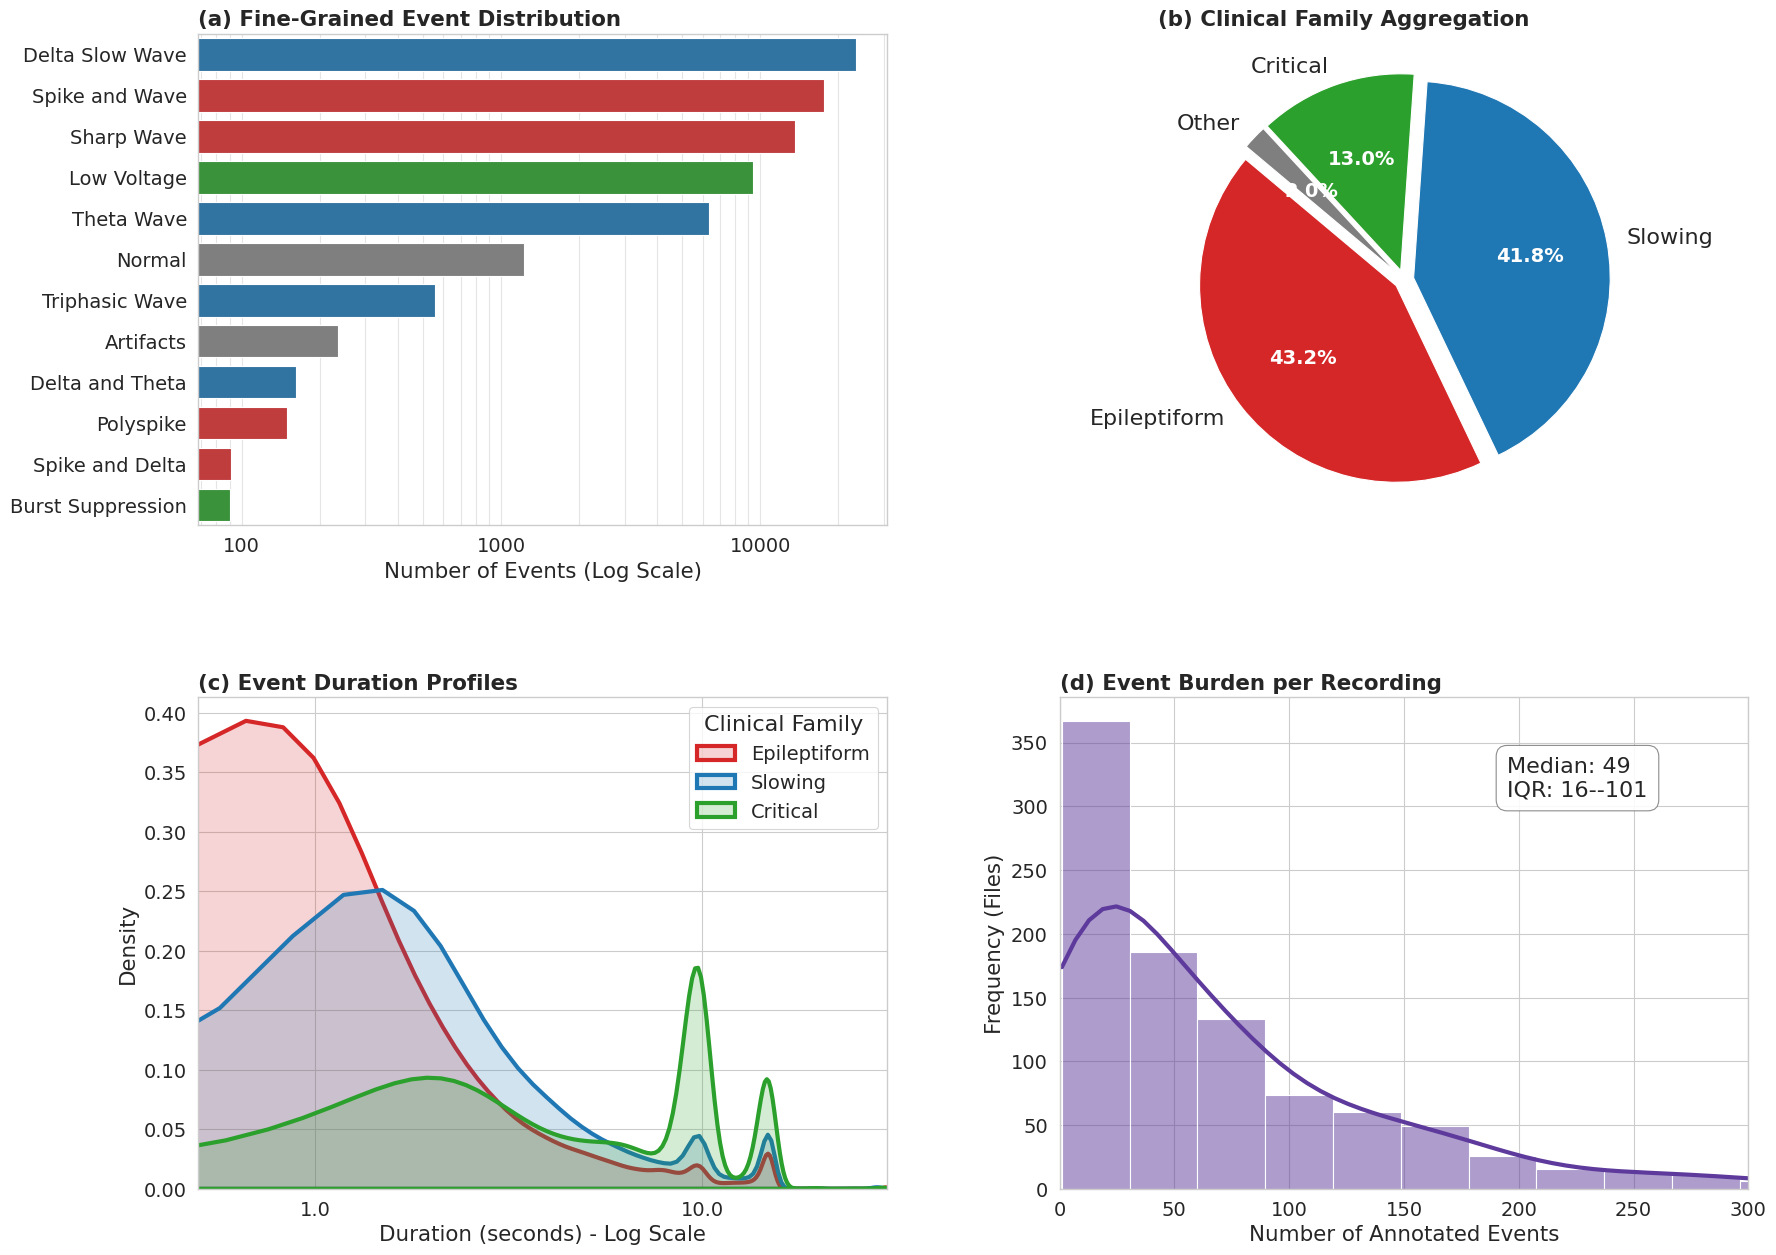

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import matplotlib.ticker as ticker

# ==========================================
# CONFIGURATION
# ==========================================
# Update this path to your actual dataset location
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")
CSV_FOLDER = ROOT_PATH / "csv_fixed_channels_fczpz_updated"
OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)

# PLOT STYLE - INCREASED FONT SIZES
# Increased font_scale from 1.2 to 1.6 for publication readability
sns.set_theme(style="whitegrid", context="paper", font_scale=1.6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (20, 15) # Slightly larger canvas
COLORS = sns.color_palette("deep")

# ==========================================
# 1. TAXONOMY & HELPERS
# ==========================================
FAMILY_MAP = {
    # Critical
    'Burst Suppression': 'Critical',
    'Low Voltage': 'Critical',
    # Epileptiform
    'Spike and Wave': 'Epileptiform',
    'Polyspike': 'Epileptiform',
    'Sharp Wave': 'Epileptiform',
    'Spike and Delta': 'Epileptiform',
    # Slowing
    'Triphasic Wave': 'Slowing',
    'Delta Slow Wave': 'Slowing',
    'Theta Wave': 'Slowing',
    'Delta and Theta Wave': 'Slowing',
    'Delta and Theta': 'Slowing', 
    # Other
    'Artifacts': 'Other',
    'Normal': 'Other'
}

FAMILY_COLORS = {
    'Epileptiform': '#d62728', # Red
    'Slowing': '#1f77b4',      # Blue
    'Critical': '#2ca02c',     # Green
    'Other': '#7f7f7f'         # Gray
}

def get_duration(start_str, end_str):
    """Parses HH:MM:SS:mmm or HH:MM:SS.mmm strings to seconds."""
    def parse_sec(t_str):
        try:
            t_str = str(t_str).replace(':', '.')
            parts = t_str.split('.')
            if len(parts) == 4: # H, M, S, mmm
                h, m, s, ms = map(int, parts)
                return h * 3600 + m * 60 + s + ms / 1000.0
            elif len(parts) == 3: # H, M, S
                 h, m, s = map(int, parts)
                 return h * 3600 + m * 60 + s
            return np.nan
        except:
            return np.nan

    s = parse_sec(start_str)
    e = parse_sec(end_str)
    if pd.notna(s) and pd.notna(e) and e > s:
        return e - s
    return np.nan

# ==========================================
# 2. DATA LOADING
# ==========================================
def load_data():
    print("Loading data for plotting...")
    csv_files = list(CSV_FOLDER.glob("*.csv"))
    
    all_events = []
    file_burdens = []
    
    for f in tqdm(csv_files):
        try:
            df = pd.read_csv(f)
            col_map = {c.strip().lower(): c for c in df.columns}
            
            col_comment = col_map.get('comment') or next((c for c in df.columns if 'label' in c.lower()), None)
            col_start = col_map.get('start time')
            col_end = col_map.get('end time')
            
            if not col_comment: continue

            file_burdens.append(len(df))
            
            for idx, row in df.iterrows():
                label = str(row[col_comment]).strip()
                if label == 'Delta and Theta Wave': label = 'Delta and Theta' 
                
                lookup_label = label if label in FAMILY_MAP else 'Other'
                if label == 'Delta and Theta' and 'Delta and Theta Wave' in FAMILY_MAP:
                     lookup_label = 'Delta and Theta Wave'
                
                family = FAMILY_MAP.get(lookup_label, 'Other')
                
                dur = np.nan
                if col_start and col_end:
                    dur = get_duration(row[col_start], row[col_end])
                
                all_events.append({
                    'Label': label,
                    'Family': family,
                    'Duration': dur
                })
                
        except Exception as e:
            pass
            
    return pd.DataFrame(all_events), np.array(file_burdens)

# ==========================================
# 3. PLOTTING
# ==========================================
def create_grid_plot(df, burdens):
    print("Generating figures...")
    
    # Increased figure size to accommodate larger fonts
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)
    
    # -------------------------------------------------------
    # (a) Detailed Label Distribution (Horizontal Bar)
    # -------------------------------------------------------
    ax1 = fig.add_subplot(gs[0, 0])
    
    counts = df['Label'].value_counts()
    
    bar_colors = []
    for lbl in counts.index:
        lookup = lbl
        if lbl == 'Delta and Theta': lookup = 'Delta and Theta Wave'
        fam = FAMILY_MAP.get(lookup, 'Other')
        bar_colors.append(FAMILY_COLORS.get(fam, '#7f7f7f'))
        
    sns.barplot(x=counts.values, y=counts.index, palette=bar_colors, ax=ax1, orient='h')
    
    ax1.set_title('(a) Fine-Grained Event Distribution', fontweight='bold', loc='left')
    ax1.set_xlabel('Number of Events (Log Scale)')
    ax1.set_xscale('log') 
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
    ax1.grid(True, axis='x', alpha=0.5, which='both')
    
    # -------------------------------------------------------
    # (b) Aggregated Family Distribution
    # -------------------------------------------------------
    ax2 = fig.add_subplot(gs[0, 1])
    
    fam_counts = df['Family'].value_counts()
    order = ['Epileptiform', 'Slowing', 'Critical', 'Other']
    fam_counts = fam_counts.reindex(order).fillna(0)
    
    patches, texts, autotexts = ax2.pie(
        fam_counts, 
        labels=fam_counts.index,
        autopct='%1.1f%%', 
        startangle=140,
        colors=[FAMILY_COLORS[x] for x in order],
        explode=(0.05, 0.05, 0.05, 0.05),
        textprops={'fontsize': 16} # Explicitly increased pie label size
    )
    
    # Fix percentage text inside pie
    for t in autotexts: 
        t.set_color('white')
        t.set_fontweight('bold')
        t.set_fontsize(14) # Explicitly increased % size
    
    ax2.set_title('(b) Clinical Family Aggregation', fontweight='bold', loc='left')
    
    # -------------------------------------------------------
    # (c) Duration Distribution (KDE by Family)
    # -------------------------------------------------------
    ax3 = fig.add_subplot(gs[1, 0])
    
    valid_dur = df[df['Duration'].between(0.1, 60)].copy() 
    
    for fam in ['Epileptiform', 'Slowing', 'Critical']:
        subset = valid_dur[valid_dur['Family'] == fam]
        sns.kdeplot(
            data=subset, x='Duration', 
            label=fam, color=FAMILY_COLORS[fam], 
            fill=True, alpha=0.2, linewidth=3, ax=ax3, warn_singular=False
        )
        
    ax3.set_title('(c) Event Duration Profiles', fontweight='bold', loc='left')
    ax3.set_xlabel('Duration (seconds) - Log Scale')
    ax3.set_xscale('log')
    ax3.set_xlim(0.5, 30)
    ax3.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax3.legend(title='Clinical Family', fontsize=14, title_fontsize=16)
    
    # -------------------------------------------------------
    # (d) Event Burden (Histogram)
    # -------------------------------------------------------
    ax4 = fig.add_subplot(gs[1, 1])
    
    sns.histplot(burdens, bins=40, color='#5D3A9B', kde=True, ax=ax4, line_kws={'linewidth': 3})
    
    ax4.set_title('(d) Event Burden per Recording', fontweight='bold', loc='left')
    ax4.set_xlabel('Number of Annotated Events')
    ax4.set_ylabel('Frequency (Files)')
    ax4.set_xlim(0, 300) 
    
    # Add Median/IQR annotation
    med = np.median(burdens)
    q1, q3 = np.percentile(burdens, [25, 75])
    stats_text = f"Median: {int(med)}\nIQR: {int(q1)}--{int(q3)}"
    
    # Increased fontsize for the annotation box
    ax4.text(0.65, 0.8, stats_text, transform=ax4.transAxes, fontsize=16,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))
    
    # Save
    out_file = OUTPUT_DIR / "fig_event_qc_grid.png"
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {out_file}")

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    df, burdens = load_data()
    if not df.empty:
        create_grid_plot(df, burdens)
    else:
        print("No data found! Check paths.")

In [49]:
import mne
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import warnings

# ==========================================
# CONFIGURATION
# ==========================================
ROOT_PATH = Path("/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/")

def validate_and_catch_nulls():
    print(f"Scanning for corrupted EDF headers in: {ROOT_PATH}")
    
    edf_files = list(ROOT_PATH.rglob("*.edf"))
    print(f"Found {len(edf_files)} files. Checking for null-byte errors...\n")
    
    results = []
    
    for f in tqdm(edf_files):
        status = "Valid"
        error_msg = ""
        
        try:
            # Catch warnings (MNE often warns before crashing on bad headers)
            with warnings.catch_warnings(record=True):
                warnings.simplefilter("ignore")
                # Attempt to read header only (preload=False)
                mne.io.read_raw_edf(f, preload=False, verbose=False)
                
        except ValueError as e:
            # This is where the "invalid literal for int()" error is caught
            msg = str(e)
            if "\\x00" in msg or "invalid literal for int()" in msg:
                status = "Critical Header Corruption (Null Bytes)"
                error_msg = msg
            else:
                status = "ValueError"
                error_msg = msg
                
        except Exception as e:
            # Catch other random corruptions
            status = "Other Error"
            error_msg = str(e)
            
        # If it wasn't valid, log it
        if status != "Valid":
            results.append({
                "file": f.name,
                "path": str(f),
                "status": status,
                "error": error_msg
            })

    # REPORTING
    print("\n" + "="*50)
    print("CORRUPTION REPORT")
    print("="*50)
    
    if len(results) == 0:
        print("✅ Success! No null-byte header errors found.")
    else:
        print(f"❌ Found {len(results)} corrupted files.")
        df = pd.DataFrame(results)
        
        # Save to CSV so you can see which ones to delete/fix
        csv_name = "corrupted_files_report.csv"
        df.to_csv(csv_name, index=False)
        
        print(f"\nBreakdown of Errors:")
        print(df['status'].value_counts())
        
        print(f"\nList of Corrupted Files saved to: {csv_name}")
        print("-" * 50)
        # Print first 5 bad files to screen
        print(df[['file', 'status']].head(5).to_string(index=False))

if __name__ == "__main__":
    validate_and_catch_nulls()

Scanning for corrupted EDF headers in: /media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split
Found 8000 files. Checking for null-byte errors...



100%|██████████| 8000/8000 [00:08<00:00, 909.85it/s]


CORRUPTION REPORT
✅ Success! No null-byte header errors found.
